# Work on netfix data

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [8]:
# Load the data
df = pd.read_csv("C:\\PYTHON JOURNEY\\PANDAS.py\\netflix_Data.csv" )
df

,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
0,s1,Movie,Stranger Things,The Duffer Brothers,United States,"September 25, 2021",2016,TV-MA,4 Seasons,"TV Dramas, Sci-Fi"
1,s2,TV Show,Sacred Games,Anurag Kashyap,India,"September 24, 2021",2018,TV-MA,2 Seasons,"Crime TV Shows, International"
2,s3,Movie,Inception,Christopher Nolan,United States,"September 24, 2021",2010,PG-13,148 min,"Action, Sci-Fi"
3,s4,Movie,3 Idiots,Rajkumar Hirani,India,"September 24, 2021",2009,PG-13,170 min,"Comedies, Dramas"
4,s5,TV Show,Money Heist,NaN,Spain,"September 10, 2021",2017,TV-MA,5 Seasons,Crime TV Shows
5,s6,Movie,The Dark Knight,Christopher Nolan,United States,"September 1, 2021",2008,PG-13,152 min,"Action, Crime"
6,s7,TV Show,Breaking Bad,NaN,United States,"August 28, 2021",2008,TV-MA,5 Seasons,Crime TV Shows
7,s8,Movie,Dangal,Nitesh Tiwari,India,"August 21, 2021",2016,PG,161 min,"Action, Dramas"
8,s9,Movie,Interstellar,Christopher Nolan,United States,"August 15, 2021",2014,PG-13,169 min,"Sci-Fi, Adventure"
9,s10,TV Show,Friends,NaN,United States,"August 1, 2021",1994,TV-14,10 Seasons,TV Comedies


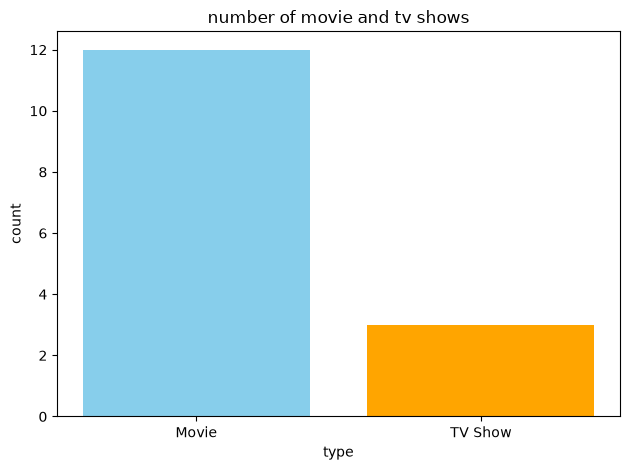

In [12]:
# Clean the data
df =df.dropna(subset=['show_id','type',	'title','director','country','date_added','release_year','rating','duration','listed_in'])

type_count = df['type'].value_counts()
plt.Figure(figsize=(10,5))
plt.bar(type_count.index,type_count.values,color=['skyblue','orange'])
plt.title('number of movie and tv shows')
plt.xlabel('type')
plt.ylabel('count') 
plt.tight_layout()
plt.show()



# pie chart

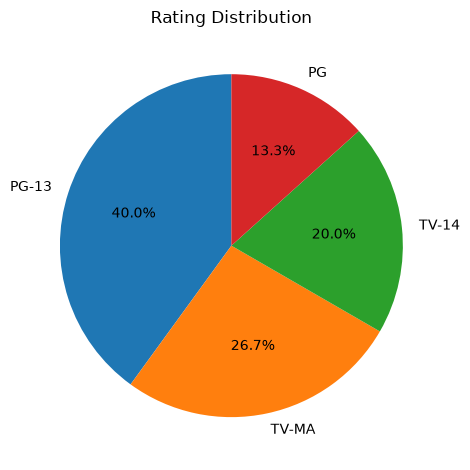

In [17]:
rating_counts = df['rating'].value_counts()
plt.Figure(figsize=(8,8))
plt.pie(rating_counts, labels=rating_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Rating Distribution')
plt.tight_layout()
plt.show()

# Histogram


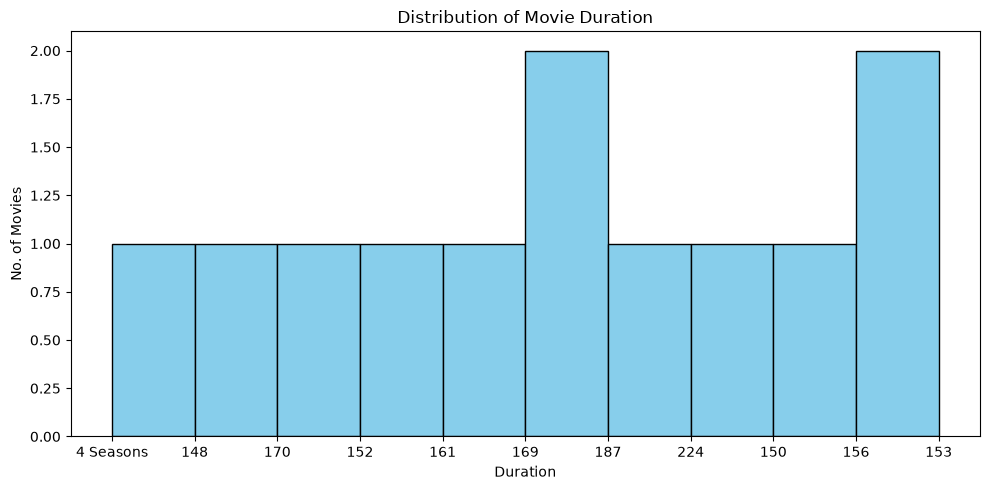

In [20]:
movie_df = df[df['type'] == 'Movie'].copy()
movie_df['duration_int'] = movie_df['duration'].astype(str).str.replace('min','',regex=False).str.strip()

plt.figure(figsize=(10,5))
plt.hist(movie_df['duration_int'],bins=10,color='skyblue',edgecolor='black')
plt.xlabel('Duration')
plt.ylabel('No. of Movies') 
plt.title('Distribution of Movie Duration')
plt.tight_layout()
plt.show()

# Scatter plot

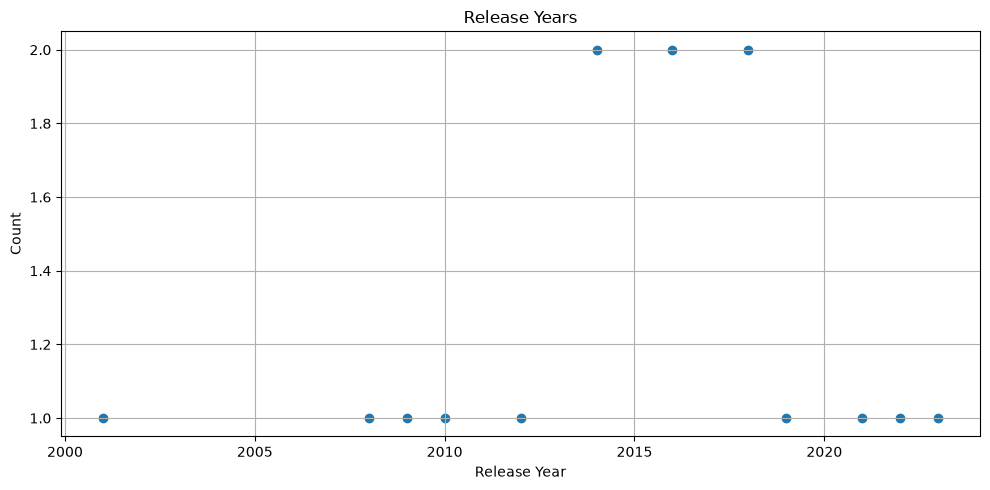

In [22]:
release_year = df['release_year'].value_counts().sort_index()
plt.figure(figsize=(10,5))
plt.scatter(release_year.index,release_year.values)
plt.xlabel('Release Year')
plt.ylabel('Count')
plt.title('Release Years')
plt.tight_layout()
plt.grid(True)
plt.show()


# Subplots

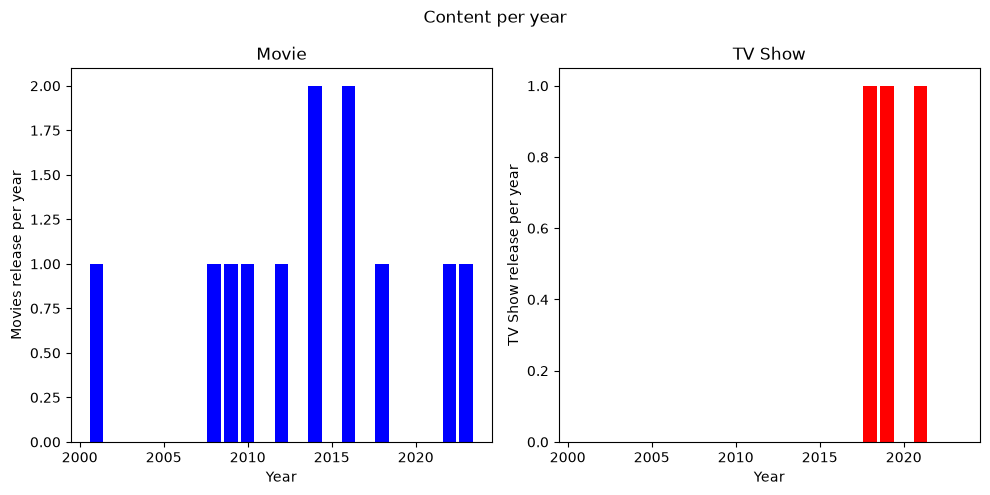

In [25]:
content_year = df.groupby(['release_year','type']).size().unstack().fillna(0)

fig , ax = plt.subplots(1,2,figsize=(10,5))

# first subplot movie
ax[0].bar(content_year.index,content_year['Movie'],color='blue')
ax[0].set_title('Movie')
ax[0].set_xlabel('Year')
ax[0].set_ylabel('Movies release per year')

# second subplot TV show
ax[1].bar(content_year.index,content_year['TV Show'],color='red')
ax[1].set_title('TV Show')
ax[1].set_xlabel('Year')
ax[1].set_ylabel('TV Show release per year')

plt.suptitle('Content per year')
plt.tight_layout() #to make the plot fit in the window
plt.show()